In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

In [ ]:
data = pd.read_csv("/content/Train.csv")
data
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 24 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Employee_ID                7000 non-null   object 
 1   Gender                     7000 non-null   object 
 2   Age                        6588 non-null   float64
 3   Education_Level            7000 non-null   int64  
 4   Relationship_Status        7000 non-null   object 
 5   Hometown                   7000 non-null   object 
 6   Unit                       7000 non-null   object 
 7   Decision_skill_possess     7000 non-null   object 
 8   Time_of_service            6856 non-null   float64
 9   Time_since_promotion       7000 non-null   int64  
 10  growth_rate                7000 non-null   int64  
 11  Travel_Rate                7000 non-null   int64  
 12  Post_Level                 7000 non-null   int64  
 13  Pay_Scale                  6991 non-null   float

После обработки данных в датафрейме были выполнены следующие шаги:

1) **Замена нечисловых значений с максимум 2 аргументами**:
Все категориальные переменные, которые принимают не более двух уникальных значений, были преобразованы в бинарные значения:

*   Первый аргумент заменен на 0.
*   Второй аргумент заменен на 1.


2) **Удаление нечисловых значений с более чем 2 аргументами**:
Все категориальные переменные, которые принимают более двух уникальных значений, были удалены из датафрейма, так как их нельзя было однозначно преобразовать в числовой формат.

3) **Создание нового датафрейма**:
На основе выполненных преобразований был создан новый датафрейм, содержащий только числовые данные и бинарные переменные. Это позволяет использовать его для дальнейшего анализа или построения моделей машинного обучения.

Итоговый датафрейм стал более структурированным и готовым для применения статистических методов или алгоритмов.

In [ ]:
data["Gender"] = data["Gender"].replace({"M": 1, "F": 0})
data["Relationship_Status"] = data["Relationship_Status"].replace({"Married": 1, "Single": 0})

mask_numeric = data.select_dtypes(include=['float64', 'int64']).columns
mask_categorical = data.nunique() <= 2
mask_combined = mask_categorical | data.columns.isin(mask_numeric)

new_data = data.loc[:, mask_combined]

numeric_columns = data.select_dtypes(include=['float64', 'int64']).columns
new_data[numeric_columns] = new_data[numeric_columns].fillna(new_data[numeric_columns].mean())

print(new_data.isna().sum())

new_data.to_csv("Train-1_modified.csv", index=False)

Gender                  0
Age                     0
Education_Level         0
Relationship_Status     0
Time_of_service         0
Time_since_promotion    0
growth_rate             0
Travel_Rate             0
Post_Level              0
Pay_Scale               0
Work_Life_balance       0
VAR1                    0
VAR2                    0
VAR3                    0
VAR4                    0
VAR5                    0
VAR6                    0
VAR7                    0
Attrition_rate          0
dtype: int64


<ipython-input-5-600df3580c2c>:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data["Gender"] = data["Gender"].replace({"M": 1, "F": 0})
<ipython-input-5-600df3580c2c>:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data["Relationship_Status"] = data["Relationship_Status"].replace({"Married": 1, "Single": 0})
<ipython-input-5-600df3580c2c>:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: h

Матрица кореляции

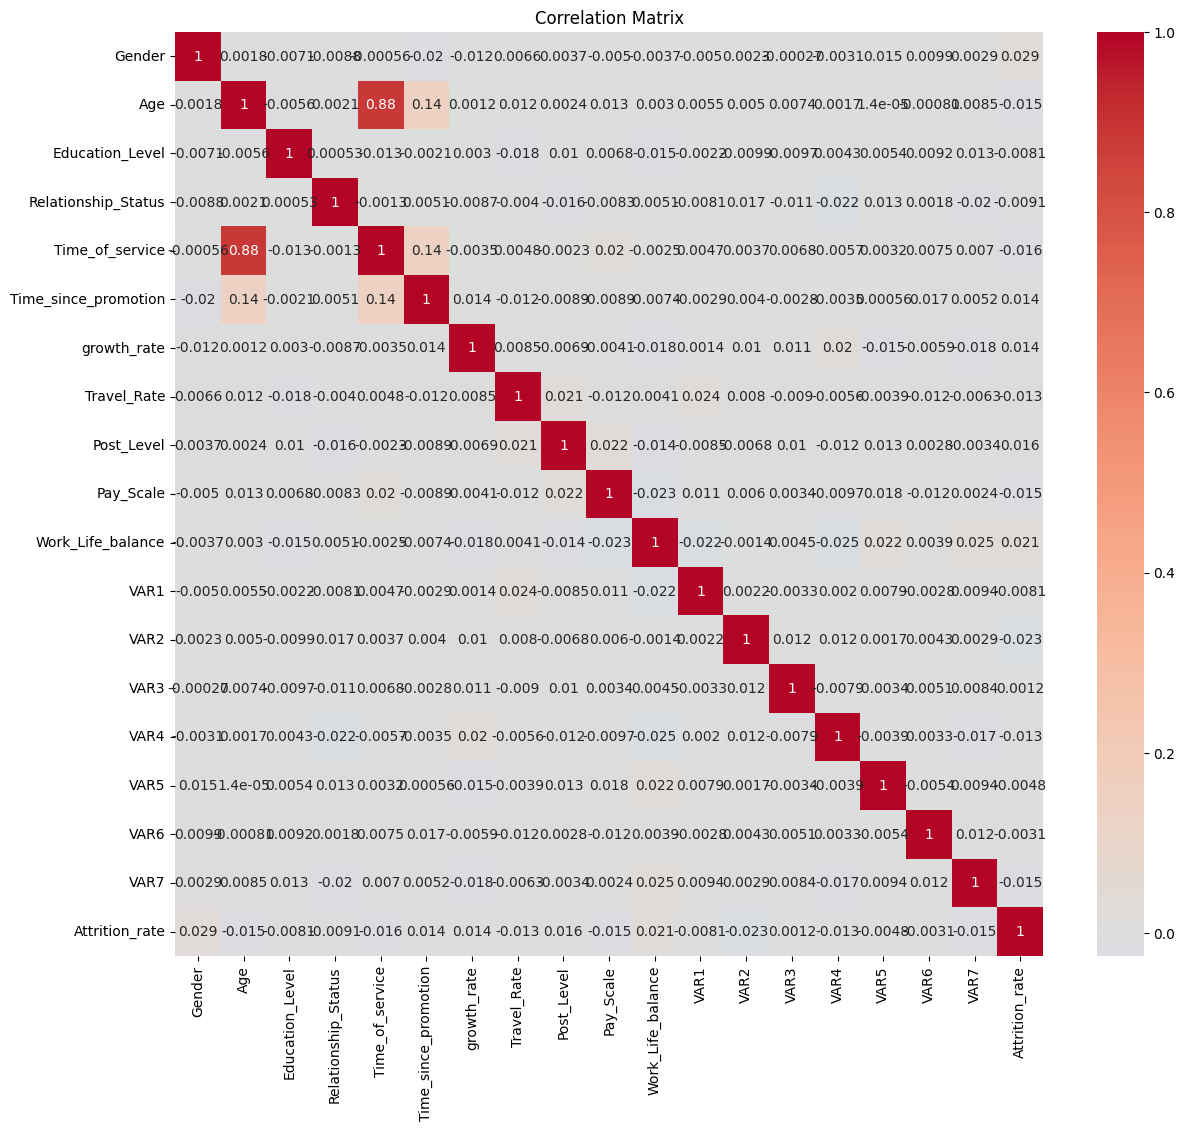

In [17]:
plt.figure(figsize=(14,12))
correlation = new_data.corr(numeric_only=True)
sns.heatmap(correlation, xticklabels=correlation.columns, yticklabels=correlation.columns, cmap='coolwarm', center=0, annot=True)
plt.title("Correlation Matrix")
plt.show()

In [ ]:
X = new_data.loc[:, 'Gender':'VAR7']
y = new_data['Attrition_rate']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)
lig_reg = LinearRegression()
lig_reg.fit(X_train, y_train)


LinearRegression()

In [ ]:
k0 = lig_reg.intercept_
k0

0.19569162555556668

In [ ]:
k1 = lig_reg.coef_
k1

array([ 1.01952986e-02, -1.20095575e-04,  1.24942294e-03, -5.83594036e-03,
       -3.77936751e-04,  1.89811425e-03,  9.14203096e-05, -4.92886424e-03,
        3.50181200e-03, -5.25634733e-04,  2.48458975e-03, -1.02438446e-03,
       -2.41360804e-03, -2.55252927e-03, -3.11074219e-03,  8.40355828e-04,
        7.21023636e-04, -5.31105959e-03])

In [ ]:
y_pred = lig_reg.predict(X_test)

print('Mean Absolute Error:', mean_absolute_error(y_test, y_pred))
print('Mean Squared Error:', mean_squared_error(y_test, y_pred))
print('R2 score:', r2_score(y_test, y_pred))

Mean Absolute Error: 0.12803000243066381
Mean Squared Error: 0.0352291755853693
R2 score: -0.0007701586223902712


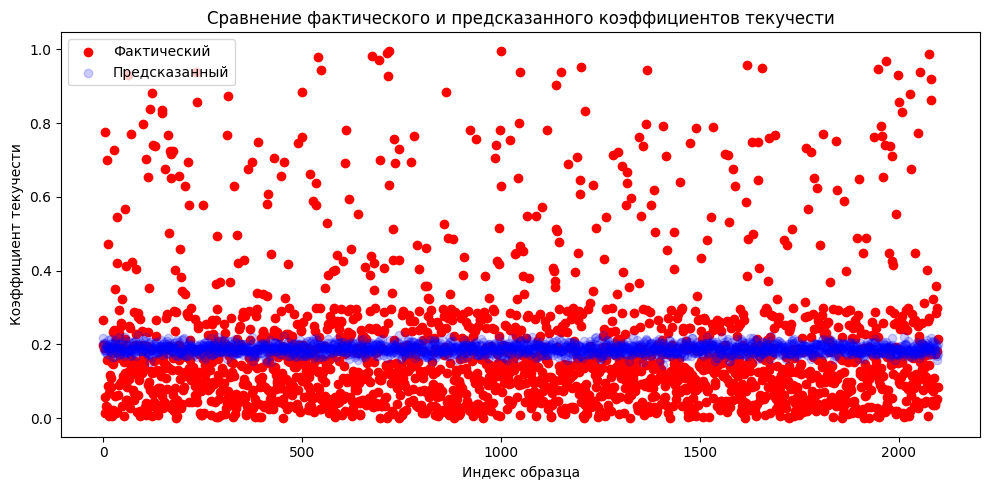

In [ ]:
plt.figure(figsize=(10, 5))
plt.scatter(range(len(y_test)), y_test, label='Фактический', color='red', alpha=1)
plt.scatter(range(len(y_pred)), y_pred, label='Предсказанный', color='blue', alpha=0.2)
plt.title('Сравнение фактического и предсказанного коэффициентов текучести')
plt.xlabel('Индекс образца')
plt.ylabel('Коэффициент текучести')
plt.legend()
plt.tight_layout()
plt.show()